<a href="https://colab.research.google.com/github/nandayot/RNA/blob/main/RNA_Trabalho1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import copy
import torch
import pickle
import requests
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.models as models
import torchvision.transforms as transforms

from PIL import Image
from io import BytesIO
from torchvision.datasets import CIFAR100
from sklearn.metrics import classification_report
from torch.utils.data import DataLoader, Subset, random_split

# googlenet 6624904
# mobilenet_v3_large 5483032
# mnasnet1_0 4383312
# mobilenet_v2 3504872
# shufflenet_v2_x1_0 2278604
# squeezenet1_0 1248424

# codigo baseado em https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

#### Escolha do Modelo
GoogLeNet

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
model = models.googlenet(pretrained=True)
count_parameters(model)

6624904

#### Dataset Customizado
CIFAR100

In [ ]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [ ]:
# url https://image.itmedia.co.jp/ait/articles/2006/15/di-01.png
SUPERCLASSES_ORIGINAL = [
    'aquatic_mammals', 'fish', 'flowers', 'food_containers', 'fruit_and_vegetables',
    'household_electrical_devices', 'household_furniture', 'insects', 'large_carnivores',
    'large_man-made_outdoor_things', 'large_natural_outdoor_scenes', 'large_omnivores_and_herbivores',
    'medium_mammals', 'non-insect_invertebrates', 'people', 'reptiles', 'small_mammals',
    'trees', 'vehicles_1', 'vehicles_2'
]
# Nomes para as 10 NOVAS superclasses (agrupando as 20 originais)
SUPERCLASSES_10 = [
    'aquatic_life',                                         # (aquatic_mammals, fish)
    'food_containers_and_fruit_and_vegetables',             # (food_containers, fruit_and_vegetables)
    'household_and_furniture',                              # (household_furniture, household_electrical_devices)
    'insects_and_non_insect_invertebrates_and_reptiles',    # (insects, non-insect_invertebrates, reptiles)
    'large_carnivores_and_large_omnivores_and_herbivores',  # (large_carnivores, large_omnivores_and_herbivores)
    'man_made_outdoor_things_outdoor_scenes',               # (large_man-made_outdoor_things, large_natural_outdoor_scenes)
    'small_mammals_and_medium_mammals',                     # (small_mammals, medium_mammals)
    'people',                                               # (people)
    'trees_and_flowers',                                    # (trees, flowers)
    'vehicles'                                              # (vehicles_1, vehicles_2)
]

# Mapeiando os índices da classe para as novas superclasses de 10 grupos
SUPERCLASSES_10_MAP = {
    # 'aquatic_life'
    0: 0,  # 'aquatic_mammals'
    1: 0,  # 'fish'

    # 'food_containers_and_fruit_and_vegetables'
    3: 1,  # 'food_containers'
    4: 1,  # 'fruit_and_vegetables'

    # 'household_and_furniture'
    5: 2,  # 'household_electrical_devices'
    6: 2,  # 'household_furniture'

    # 'insects_and_non_insect_invertebrates_and_reptiles'
    7: 3,  # 'insects'
    13: 3, # 'non-insect_invertebrates'
    15: 3, # 'reptiles'

    # 'large_carnivores_and_large_omnivores_and_herbivores'
    8: 4,  # 'large_carnivores'
    11: 4, # 'large_omnivores_and_herbivores'

    # 'man_made_outdoor_things_and_large_natural_outdoor_scenes'
    9: 5,  # 'large_man-made_outdoor_things'
    10: 5, # 'large_natural_outdoor_scenes'

    # 'small_mammals_and_medium_mammals'
    12: 6, # 'medium_mammals'
    16: 6, # 'small_mammals'

    # 'people'
    14: 7, # 'people'

    # 'trees_and_flowers'
    2: 8,  # 'flowers'
    17: 8, # 'trees'

    # 'vehicles'
    18: 9, # 'vehicles_1'
    19: 9  # 'vehicles_2'
}

CLASSES_FINAS_100 = ['apple',  'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly',
 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin',
 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man',
 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain',
 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail',
 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip',
 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']

Dataset CIFAR-100

In [ ]:
class CIFAR100Custom(CIFAR100):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        if self.train:
            filename = self.train_list[0][0]
        else:
            filename = self.test_list[0][0]

        file_path = os.path.join(self.root, self.base_folder, filename)

        print(f"Carregando rótulos de superclasse de: {file_path}")
        entry = unpickle(file_path)
        self.custom_coarse_targets = entry[b'coarse_labels']

    def __getitem__(self, index):
        img, fine_target = super().__getitem__(index)

        coarse_target_20 = self.custom_coarse_targets[index]
        coarse_target_10 = SUPERCLASSES_10_MAP[coarse_target_20]

        return img, coarse_target_20, coarse_target_10, fine_target

#### MODELOS
- GoogLeNet e GoogLeNet Multihead

Modelo GoogLeNet

In [ ]:
def get_googlenet_model(num_classes):
    model = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)
    model.aux_logits = False
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    return model

Modelo Multi-Head GoogLeNet

In [ ]:
class MultiHeadGoogLeNet(nn.Module):
    def __init__(self, num_classes_10, num_classes_100):
        super(MultiHeadGoogLeNet, self).__init__()
        googlenet = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)
        googlenet.aux_logits = False
        self.num_features = googlenet.fc.in_features

        # Backbone sem a camada final
        googlenet.fc = nn.Identity()
        self.backbone = googlenet

        # Cabeças de classificação com MLP simples
        self.head10 = nn.Sequential(
            nn.Linear(self.num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes_10)
        )
        self.head100 = nn.Sequential(
            nn.Linear(self.num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes_100)
        )

    def forward(self, x):
        features = self.backbone(x)
        out10 = self.head10(features)
        out100 = self.head100(features)
        return {'super_10': out10, 'fine_100': out100}

#### Treinamento

In [ ]:
def treinamento(model, model_type, train_loader, val_loader, criterion, optimizer, num_epochs, early_stop, checkpoint_path, device):
    log_loss_treino = []
    log_loss_validacao = []

    loss_otima = float('inf')
    epocas_sem_melhora = 0
    melhor_modelo = None

    for epoch in range(num_epochs):
        model.train()
        loss_treinamento = 0.0

        for images, superclasses_20, superclasses_10, classes in train_loader:
            images = images.to(device)
            superclasses_20 = superclasses_20.to(device)
            superclasses_10 = superclasses_10.to(device)
            classes = classes.to(device)

            # zera os pesos para cada batch
            optimizer.zero_grad()

            # Cálculo da loss baseado no tipo de modelo
            if model_type == 'single_20':
                outputs = model(images)
                loss = criterion(outputs, superclasses_20)
            elif model_type == 'single_100':
                outputs = model(images)
                loss = criterion(outputs, classes)
            elif model_type == 'multi':
                outputs = model(images)
                loss_10 = criterion(outputs['super_10'], superclasses_10)
                loss_100 = criterion(outputs['fine_100'], classes)
                loss = loss_10 + loss_100 # soma das loss

            # backpropagation
            loss.backward()

            # atualização de pesos
            optimizer.step()
            loss_treinamento += loss.item() * images.size(0)

        loss_por_epoca = loss_treinamento / len(train_loader.dataset)
        log_loss_treino.append(loss_por_epoca)

        # Validação
        model.eval()
        loss_validacao = 0.0
        with torch.no_grad():
            for images, superclasses_20, superclasses_10, classes in val_loader:
                images = images.to(device)
                superclasses_20 = superclasses_20.to(device)
                superclasses_10 = superclasses_10.to(device)
                classes = classes.to(device)

                # Cálculo da loss baseado no tipo de modelo
                if model_type == 'single_20':
                    outputs = model(images)
                    loss = criterion(outputs, superclasses_20)
                elif model_type == 'single_100':
                    outputs = model(images)
                    loss = criterion(outputs, classes)
                elif model_type == 'multi':
                    outputs = model(images)
                    loss_10 = criterion(outputs['super_10'], superclasses_10)
                    loss_100 = criterion(outputs['fine_100'], classes)
                    loss = loss_10 + loss_100

                loss_validacao += loss.item() * images.size(0)

        loss_validacao_por_epoca = loss_validacao / len(val_loader.dataset)
        log_loss_validacao.append(loss_validacao_por_epoca)

        print(f"Época {epoch+1}/{num_epochs} - Loss Treino: {loss_por_epoca:.4f} - Loss Validação: {loss_validacao_por_epoca:.4f}")

        # Checkpoint e Early Stop
        if loss_validacao_por_epoca < loss_otima:
            loss_otima = loss_validacao_por_epoca
            epocas_sem_melhora = 0
            melhor_modelo = copy.deepcopy(model.state_dict())
            torch.save(melhor_modelo, checkpoint_path)
            print(f"Melhor modelo salvo em {checkpoint_path}\n")
        else:
            epocas_sem_melhora += 1

        if epocas_sem_melhora >= early_stop:
            print(f"Early stop ativado na época {epoch+1}.\n")
            break

    # Carrega o melhor modelo salvo e retorna
    if melhor_modelo:
        model.load_state_dict(melhor_modelo)

    return model, log_loss_treino, log_loss_validacao

Avaliação

In [ ]:
def avaliacao(model, model_type, test_loader, classes_finas, device):
    model.eval()

    all_preds_20, all_labels_20 = [], []
    all_preds_10, all_labels_10 = [], []
    all_preds_100, all_labels_100 = [], []

    with torch.no_grad():
        for images, superclasses_20, superclasses_10, classes in test_loader:
            images = images.to(device)

            if model_type == 'single_20':
                outputs = model(images)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                all_preds_20.extend(preds)
                all_labels_20.extend(superclasses_20.numpy())
            elif model_type == 'single_100':
                outputs = model(images)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                all_preds_100.extend(preds)
                all_labels_100.extend(classes.numpy())
            else:
                outputs = model(images)
                preds_10 = torch.argmax(outputs['super_10'], dim=1).cpu().numpy()
                preds_100 = torch.argmax(outputs['fine_100'], dim=1).cpu().numpy()

                all_preds_10.extend(preds_10)
                all_labels_10.extend(superclasses_10.numpy())
                all_preds_100.extend(preds_100)
                all_labels_100.extend(classes.numpy())

    print("\nClassification Report")
    if model_type in ['single_20']:
        print("\nModelo de 20 Superclasses")
        print(classification_report(all_labels_20, all_preds_20,
                                    target_names=SUPERCLASSES_ORIGINAL,
                                    zero_division=0))

    if model_type in ['multi']:
        print("\nModelo de 10 Superclasses (Agrupadas)")
        print(classification_report(all_labels_10, all_preds_10,
                                    target_names=SUPERCLASSES_10,
                                    zero_division=0))

    if model_type in ['single_100', 'multi']:
        print("\nModelo de 100 Classes Finas")
        print(classification_report(all_labels_100, all_preds_100,
                                    target_names=classes_finas,
                                    zero_division=0))

Plotagem

In [ ]:
def plotagem(log_treino, log_validacao):
    plt.figure(figsize=(10, 5))
    plt.plot(log_treino, label='Loss de Treinamento')
    plt.plot(log_validacao, label='Loss de Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.title('Curvas de Loss de Treino e Validação')
    plt.legend()
    plt.grid(True)
    plt.show()

#### Classificador

In [ ]:
def classificadorCIFARCustom(model_type = 'multi'):
    # 'single_20', 'single_100', ou 'multi'
    MODELO_ESCOLHIDO = model_type
    BATCH_SIZE = 64
    LEARNING_RATE = 0.001
    NUM_EPOCHS = 50
    EARLY_STOP = 7
    VALIDACAO_TAMANHO = 0.1
    NUM_WORKERS = 2
    CHECKPOINT_DIR = "./checkpoints"

    # Cria o diretório de checkpoints
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

    # Configurando GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Usando device: {device}")

    # Transforma imagens do treino (vira e rotaciona)
    mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    print("Carregando e dividindo o dataset...")
    # Carrega dataset de TREINO (50.000 imagens) e TESTE (10.000 imagens)
    dataset_treino = CIFAR100Custom(root='./data', train=True, download=True, transform=train_transform)
    dataset_teste = CIFAR100Custom(root='./data', train=False, download=True, transform=val_transform)

    # Divide o dataset de treino e pega uma parte para validação
    dataset_treino_tamanho = len(dataset_treino)
    tamanho_validacao = int(dataset_treino_tamanho * VALIDACAO_TAMANHO)
    dataset_treino_tamanho_novo = dataset_treino_tamanho - tamanho_validacao
    dataset_treino, dataset_validacao = random_split(dataset_treino, [dataset_treino_tamanho_novo, tamanho_validacao])

    # Cria DataLoaders
    train_loader = DataLoader(dataset_treino, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(dataset_validacao, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(dataset_teste, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    if MODELO_ESCOLHIDO == 'single_20':
        model_type = 'single_20'
        model = get_googlenet_model(num_classes=20)
        checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_model_20.pth')
    elif MODELO_ESCOLHIDO == 'single_100':
        model_type = 'single_100'
        model = get_googlenet_model(num_classes=100)
        checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_model_100.pth')
    else:
        model_type = 'multi'
        model = MultiHeadGoogLeNet(num_classes_10=10, num_classes_100=100)
        checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_model_multi_10_100.pth')

    model = model.to(device)

    # Loss e Otimizador
    criterion = nn.CrossEntropyLoss()
    if model_type == 'multi':
      parametros_backbone = model.backbone.parameters()
      parametros_heads = list(model.head10.parameters()) + list(model.head100.parameters())
      optimizer = optim.Adam([
          {'params': parametros_backbone, 'lr': 1e-5},
          {'params': parametros_heads, 'lr': 1e-3}
      ], lr=LEARNING_RATE)
    else:
      optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Treinamento
    print(f"Iniciando o treinamento do modelo {model_type}...")
    modelo_treinado, log_treino, log_validacao = treinamento(
        model=model,
        model_type=model_type,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        early_stop=EARLY_STOP,
        checkpoint_path=checkpoint_path,
        device=device
    )

    # Plotagem
    print("Treinamento concluído. Plotando histórico de loss...")
    plotagem(log_treino, log_validacao)

    # Avaliação do modelo
    print("Avaliando o melhor modelo no set de teste...")
    avaliacao(
        model=modelo_treinado,
        model_type=model_type,
        test_loader=test_loader,
        classes_finas=CLASSES_FINAS_100,
        device=device
    )

Usando device: cuda
Carregando e dividindo o dataset...


100%|██████████| 169M/169M [00:13<00:00, 12.1MB/s]


Carregando rótulos de superclasse de: ./data/cifar-100-python/train
Carregando rótulos de superclasse de: ./data/cifar-100-python/test
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 138MB/s]


Iniciando o treinamento do modelo single_20...
Época 1/50 - Loss Treino: 1.1565 - Loss Validação: 0.9960
Melhor modelo salvo em ./checkpoints/best_model_20.pth

Época 2/50 - Loss Treino: 0.8033 - Loss Validação: 0.8880
Melhor modelo salvo em ./checkpoints/best_model_20.pth

Época 3/50 - Loss Treino: 0.6692 - Loss Validação: 0.7993
Melhor modelo salvo em ./checkpoints/best_model_20.pth

Época 4/50 - Loss Treino: 0.5810 - Loss Validação: 0.7582
Melhor modelo salvo em ./checkpoints/best_model_20.pth

Época 5/50 - Loss Treino: 0.5107 - Loss Validação: 0.7160
Melhor modelo salvo em ./checkpoints/best_model_20.pth

Época 6/50 - Loss Treino: 0.4527 - Loss Validação: 0.7023
Melhor modelo salvo em ./checkpoints/best_model_20.pth

Época 7/50 - Loss Treino: 0.4019 - Loss Validação: 0.6769
Melhor modelo salvo em ./checkpoints/best_model_20.pth

Época 8/50 - Loss Treino: 0.3571 - Loss Validação: 0.7880
Época 9/50 - Loss Treino: 0.3206 - Loss Validação: 0.6973
Época 10/50 - Loss Treino: 0.2877 - Los

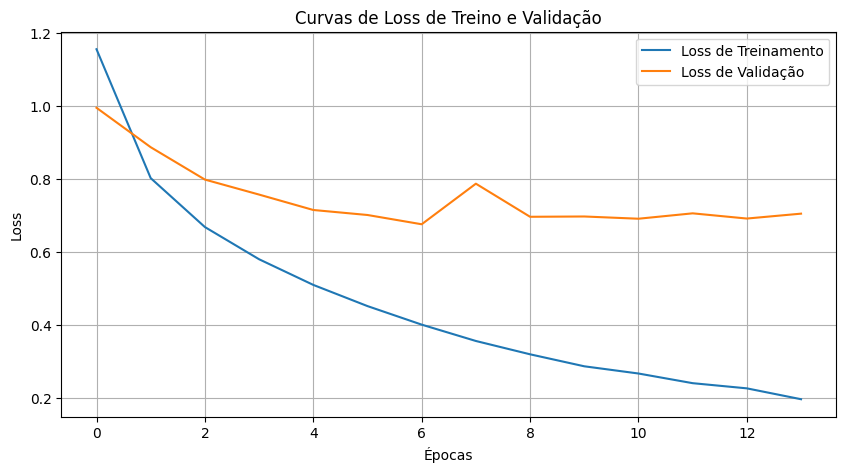

Avaliando o melhor modelo no set de teste...

Classification Report

Modelo de 20 Superclasses
                                precision    recall  f1-score   support

               aquatic_mammals       0.59      0.77      0.67       500
                          fish       0.72      0.83      0.77       500
                       flowers       0.90      0.89      0.90       500
               food_containers       0.79      0.87      0.83       500
          fruit_and_vegetables       0.90      0.85      0.88       500
  household_electrical_devices       0.83      0.75      0.79       500
           household_furniture       0.85      0.90      0.87       500
                       insects       0.78      0.83      0.81       500
              large_carnivores       0.87      0.71      0.78       500
 large_man-made_outdoor_things       0.87      0.85      0.86       500
  large_natural_outdoor_scenes       0.86      0.86      0.86       500
large_omnivores_and_herbivores       0.7

In [ ]:
classificadorCIFARCustom('single_20')

Usando device: cuda
Carregando e dividindo o dataset...
Carregando rótulos de superclasse de: ./data/cifar-100-python/train
Carregando rótulos de superclasse de: ./data/cifar-100-python/test
Iniciando o treinamento do modelo single_100...
Época 1/50 - Loss Treino: 2.0001 - Loss Validação: 1.5566
Melhor modelo salvo em ./checkpoints/best_model_100.pth

Época 2/50 - Loss Treino: 1.2796 - Loss Validação: 1.3389
Melhor modelo salvo em ./checkpoints/best_model_100.pth

Época 3/50 - Loss Treino: 1.0378 - Loss Validação: 1.1424
Melhor modelo salvo em ./checkpoints/best_model_100.pth

Época 4/50 - Loss Treino: 0.8909 - Loss Validação: 1.0673
Melhor modelo salvo em ./checkpoints/best_model_100.pth

Época 5/50 - Loss Treino: 0.7731 - Loss Validação: 1.0285
Melhor modelo salvo em ./checkpoints/best_model_100.pth

Época 6/50 - Loss Treino: 0.6776 - Loss Validação: 1.0533
Época 7/50 - Loss Treino: 0.6054 - Loss Validação: 1.0031
Melhor modelo salvo em ./checkpoints/best_model_100.pth

Época 8/50 - 

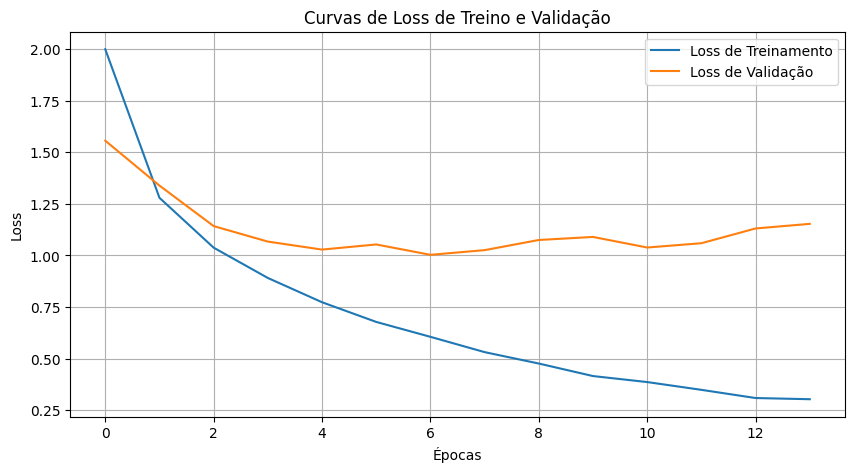

Avaliando o melhor modelo no set de teste...

Classification Report

Modelo de 100 Classes Finas
               precision    recall  f1-score   support

        apple       0.96      0.87      0.91       100
aquarium_fish       0.87      0.85      0.86       100
         baby       0.69      0.46      0.55       100
         bear       0.76      0.39      0.52       100
       beaver       0.48      0.57      0.52       100
          bed       0.82      0.64      0.72       100
          bee       0.64      0.86      0.73       100
       beetle       0.82      0.76      0.79       100
      bicycle       0.99      0.84      0.91       100
       bottle       0.88      0.88      0.88       100
         bowl       0.62      0.55      0.59       100
          boy       0.38      0.70      0.49       100
       bridge       0.76      0.76      0.76       100
          bus       0.68      0.63      0.66       100
    butterfly       0.82      0.75      0.78       100
        camel       0.

In [ ]:
classificadorCIFARCustom('single_100')

Usando device: cuda
Carregando e dividindo o dataset...
Carregando rótulos de superclasse de: ./data/cifar-100-python/train
Carregando rótulos de superclasse de: ./data/cifar-100-python/test
Iniciando o treinamento do modelo multi...
Época 1/50 - Loss Treino: 3.1578 - Loss Validação: 1.8547
Melhor modelo salvo em ./checkpoints/best_model_multi_10_100.pth

Época 2/50 - Loss Treino: 1.9082 - Loss Validação: 1.4976
Melhor modelo salvo em ./checkpoints/best_model_multi_10_100.pth

Época 3/50 - Loss Treino: 1.6222 - Loss Validação: 1.3513
Melhor modelo salvo em ./checkpoints/best_model_multi_10_100.pth

Época 4/50 - Loss Treino: 1.4492 - Loss Validação: 1.2873
Melhor modelo salvo em ./checkpoints/best_model_multi_10_100.pth

Época 5/50 - Loss Treino: 1.3253 - Loss Validação: 1.2083
Melhor modelo salvo em ./checkpoints/best_model_multi_10_100.pth

Época 6/50 - Loss Treino: 1.2302 - Loss Validação: 1.1788
Melhor modelo salvo em ./checkpoints/best_model_multi_10_100.pth

Época 7/50 - Loss Trei

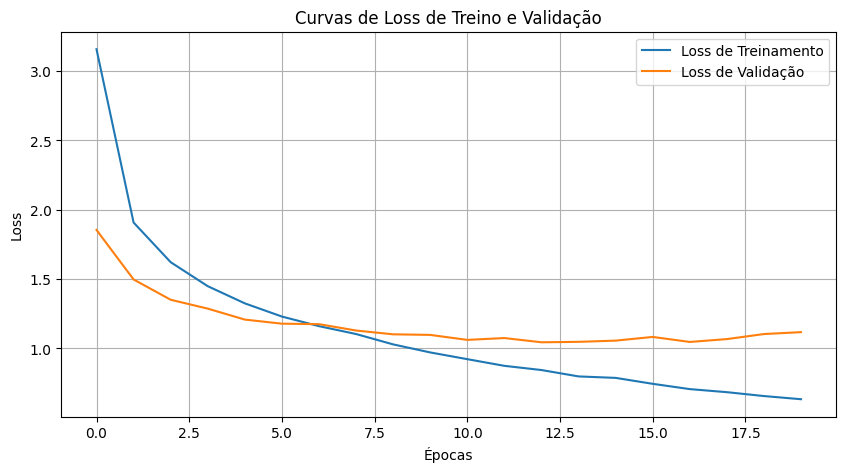

Avaliando o melhor modelo no set de teste...

Classification Report

Modelo de 10 Superclasses (Agrupadas)
                                                     precision    recall  f1-score   support

                                       aquatic_life       0.86      0.86      0.86      1000
           food_containers_and_fruit_and_vegetables       0.93      0.92      0.92      1000
                            household_and_furniture       0.95      0.93      0.94      1000
  insects_and_non_insect_invertebrates_and_reptiles       0.88      0.91      0.90      1500
large_carnivores_and_large_omnivores_and_herbivores       0.91      0.86      0.88      1000
             man_made_outdoor_things_outdoor_scenes       0.92      0.93      0.93      1000
                   small_mammals_and_medium_mammals       0.83      0.87      0.85      1000
                                             people       0.96      0.94      0.95       500
                                  trees_and_flowers    

In [ ]:
classificadorCIFARCustom('multi')

#### Predição novas imagens

In [ ]:
def predict_single_image(model_type, model_path, img, device, transform, classes_lista, superclasse_20_esperada, superclasse_10_esperada, classe_fina_esperada):
    image_tensor = transform(img).unsqueeze(0).to(device)

    if model_type == 'single_20':
        model = get_googlenet_model(num_classes=20)
    elif model_type == 'single_100':
        model = get_googlenet_model(num_classes=100)
    else:
        model = MultiHeadGoogLeNet(num_classes_10=10, num_classes_100=100)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()

    print(f"\nResultado da Predição para: {model_type}")
    with torch.no_grad():
        outputs = model(image_tensor)

        if model_type == 'multi_10_100':
            out_10 = outputs['super_10']
            probs_10 = F.softmax(out_10, dim=1)
            conf_10, pred_10 = torch.max(probs_10, 1)
            index_10 = pred_10.item()
            print(f"Superclasse 10 Esperada: {superclasse_10_esperada}")
            print(f"Superclasse 10: {classes_lista['10'][index_10]} (Confiança: {conf_10.item()*100:.2f}%)")

            out_100 = outputs['fine_100']
            probs_100 = F.softmax(out_100, dim=1)
            conf_100, pred_100 = torch.max(probs_100, 1)
            index_100 = pred_100.item()
            print(f"Classe Fina Esperada: {classe_fina_esperada}")
            print(f"Classe Fina: {classes_lista['100'][index_100]} (Confiança: {conf_100.item()*100:.2f}%)")

        else:
            probs = F.softmax(outputs, dim=1)
            confidence, prediction = torch.max(probs, 1)
            index_pred = prediction.item()

            if model_type == 'single_20':
                class_name = classes_lista['20'][index_pred]
                print(f"Superclasse 20 Esperada: {superclasse_20_esperada}")
            elif model_type == 'single_100':
                class_name = classes_lista['100'][index_pred]
                print(f"Classe Fina Esperada: {classe_fina_esperada}")
            print(f"Predição: {class_name} (Confiança: {confidence.item()*100:.2f}%)")

In [ ]:
def predict_new_images(image_url, superclasse_20_esperada, superclasse_10_esperada, classe_fina_esperada):
    image_to_test = image_url

    print("\nTeste com imagens novas")
    CHECKPOINT_DIR = "./checkpoints"
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

    mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    img_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    classes_lista = {
        '20': SUPERCLASSES_ORIGINAL,
        '10': SUPERCLASSES_10,
        '100': CLASSES_FINAS_100
    }

    model_paths = {
        'single_20': os.path.join(CHECKPOINT_DIR, 'best_model_20.pth'),
        'single_100': os.path.join(CHECKPOINT_DIR, 'best_model_100.pth'),
        'multi_10_100': os.path.join(CHECKPOINT_DIR, 'best_model_multi_10_100.pth')
    }

    try:
        response = requests.get(image_to_test)
        img = Image.open(BytesIO(response.content)).convert('RGB')
    except Exception as e:
        print(f"Erro ao carregar a imagem {image_to_test}: {e}")
        return

    plt.imshow(img)
    plt.axis('off')
    plt.show()

    for model_type, path in model_paths.items():
        predict_single_image(
            model_type=model_type,
            model_path=path,
            img=img,
            device=device,
            transform=img_transform,
            classes_lista=classes_lista,
            superclasse_20_esperada=superclasse_20_esperada,
            superclasse_10_esperada=superclasse_10_esperada,
            classe_fina_esperada=classe_fina_esperada
        )

In [ ]:
new_images_to_predict = [
    {
        'image_url': 'https://wildlifehelp.org/sites/default/files/images/species/northern_river_otter_FWS_tim_koerner.jpg',
        'superclasse_20_esperada': 'aquatic_mammals',
        'superclasse_10_esperada': 'aquatic_life',
        'classe_fina_esperada': 'otter'
    },
    {
        'image_url': 'https://cdn.britannica.com/48/117548-050-120541EE/Rainbow-trout.jpg',
        'superclasse_20_esperada': 'fish',
        'superclasse_10_esperada': 'aquatic_life',
        'classe_fina_esperada': 'trout'
    },
    {
        'image_url': 'https://www.phipps.conservatory.org/assets/images/as_standard_image/_C2A6483.JPG?v=1761223346',
        'superclasse_20_esperada': 'flowers',
        'superclasse_10_esperada': 'trees_and_flowers',
        'classe_fina_esperada': 'orchids'
    },
    {
        'image_url': 'https://cdn.shoppub.io/cdn-cgi/image/w=1000,h=1000,q=80,f=auto/casaestilo/media/uploads/produtos/foto/nytyvtfu/2.jpg',
        'superclasse_20_esperada': 'food_containers',
        'superclasse_10_esperada': 'food_containers_and_fruit_and_vegetables',
        'classe_fina_esperada': 'bowls'
    },
    {
        'image_url': 'https://extension.sdstate.edu/sites/default/files/styles/image_width_800/public/2020-11/W-00838-01-How-to-Grow-It-Peppers.jpg?itok=AWgtfDwL',
        'superclasse_20_esperada': 'fruit_and_vegetables',
        'superclasse_10_esperada': 'food_containers_and_fruit_and_vegetables',
        'classe_fina_esperada': 'sweet_peppers'
    },
    {
        'image_url': 'https://www.addisonross.com/cdn/shop/files/navy-lacquer-rechargeable-bobbin-led-lamp-5990033.jpg?v=1761333504&width=533',
        'superclasse_20_esperada': 'household_electrical_devices',
        'superclasse_10_esperada': 'household_and_furniture',
        'classe_fina_esperada': 'lamp'
    },
    {
        'image_url': 'https://thonart.com.br/imagecache/og_image/files/item-27956000-cadeira-berlim-giratoria-assento-em-madeira-v1-a.jpg',
        'superclasse_20_esperada': 'household_furniture',
        'superclasse_10_esperada': 'household_and_furniture',
        'classe_fina_esperada': 'chair'
    },
    {
        'image_url': 'https://t3.ftcdn.net/jpg/17/60/78/42/360_F_1760784285_zlPyjenvbNMdSZk5dHuEUQF5IbJDDhcL.jpg',
        'superclasse_20_esperada': 'insects',
        'superclasse_10_esperada': 'insects_and_non_insect_invertebrates_and_reptiles',
        'classe_fina_esperada': 'caterpillar'
    },
    {
        'image_url': 'https://static.toiimg.com/thumb/msid-124849101,width-1280,height-720,resizemode-4/124849101.jpg',
        'superclasse_20_esperada': 'large_carnivores',
        'superclasse_10_esperada': 'large_carnivores_and_large_omnivores_and_herbivores',
        'classe_fina_esperada': 'tiger'
    },
    {
        'image_url': 'https://www.preventionweb.net/sites/default/files/styles/ultrawide_16_6/public/Resilient-road-min.jpg?itok=822kSYjV',
        'superclasse_20_esperada': 'large_man-made_outdoor_things',
        'superclasse_10_esperada': 'man_made_outdoor_things_outdoor_scenes',
        'classe_fina_esperada': 'road'
    },
    {
        'image_url': 'https://www.gunstock.com/upload/cache/home_gallery.image/lg/homegallery_sony_11-4.jpg',
        'superclasse_20_esperada': 'large_natural_outdoor_scenes',
        'superclasse_10_esperada': 'man_made_outdoor_things_outdoor_scenes',
        'classe_fina_esperada': 'mountain'
    },
    {
        'image_url': 'https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEjM8rlZbTEiUpOfc1B99ES5-51Qa13tmNWSsvnguHwRbLmgX7RgrnigKoYJ3mO4-3iljy2Aib0JScG-2sGktRd9-2NKuh0ce0atnmgwd-ZSoin5uiqnLpf3m8ojAQ4SnqlsEavvt3ABsy0K/s1600/Bactrian+Camel.jpg',
        'superclasse_20_esperada': 'large_omnivores_and_herbivores',
        'superclasse_10_esperada': 'large_carnivores_and_large_omnivores_and_herbivores',
        'classe_fina_esperada': 'camel'
    },
    {
        'image_url': 'https://www.skedaddlewildlife.com/wp-content/uploads/2024/08/Toronto-Wildlife-Control-What-Time-Of-Day-Are-You-Most-Likely-To-See-A-Raccoon.png',
        'superclasse_20_esperada': 'medium_mammals',
        'superclasse_10_esperada': 'small_mammals_and_medium_mammals',
        'classe_fina_esperada': 'raccoon'
    },
    {
        'image_url': 'https://farm1.staticflickr.com/656/20989372871_d4a6eab17a_z.jpg',
        'superclasse_20_esperada': 'non-insect_invertebrates',
        'superclasse_10_esperada': 'insects_and_non_insect_invertebrates_and_reptiles',
        'classe_fina_esperada': 'spider'
    },
    {
        'image_url': 'https://media.bizj.us/view/img/13084533/djpeterson-2*375xx2375-2375-353-82.jpg',
        'superclasse_20_esperada': 'people',
        'superclasse_10_esperada': 'people',
        'classe_fina_esperada': 'man'
    },
    {
        'image_url': 'https://www.shutterstock.com/image-photo/lizard-genus-liolaemus-most-representative-600nw-2690471859.jpg',
        'superclasse_20_esperada': 'reptiles',
        'superclasse_10_esperada': 'insects_and_non_insect_invertebrates_and_reptiles',
        'classe_fina_esperada': 'lizard'
    },
    {
        'image_url': 'https://harvardpetparadise.com/cdn/shop/files/FullSizeRender_2783852a-f3e3-4451-9c13-230675fa8033.heic?v=1761172096&width=1946',
        'superclasse_20_esperada': 'small_mammals',
        'superclasse_10_esperada': 'small_mammals_and_medium_mammals',
        'classe_fina_esperada': 'rabbit'
    },
    {
        'image_url': 'https://www.gardendesign.com/pictures/images/900x705Max/site_3/weeping-willow-salix-babylonica-shutterstock-com_19647.jpg',
        'superclasse_20_esperada': 'trees',
        'superclasse_10_esperada': 'trees_and_flowers',
        'classe_fina_esperada': 'willow'
    },
    {
        'image_url': 'https://clickpetroleoegas.com.br/wp-content/uploads/2025/10/Imagem-CPG-redimencionada-para-google-discovery-2025-10-27T235255.106-1290x726.jpg',
        'superclasse_20_esperada': 'vehicles_1',
        'superclasse_10_esperada': 'vehicles',
        'classe_fina_esperada': 'pickup_truck'
    },
    {
        'image_url': 'https://blogto-production2-baselayer-display.blogto.com/articles/20240819-streetcar-race-ttc.jpg?w=640&cmd=resize_then_crop&height=427&quality=70&format=jpeg',
        'superclasse_20_esperada': 'vehicles_2',
        'superclasse_10_esperada': 'vehicles',
        'classe_fina_esperada': 'streetcar'
    }
]


Teste com imagens novas


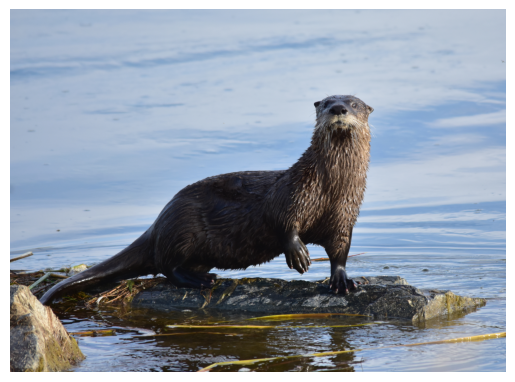


Resultado da Predição para: single_20
Superclasse 20 Esperada: aquatic_mammals
Predição: aquatic_mammals (Confiança: 99.91%)

Resultado da Predição para: single_100
Classe Fina Esperada: otter
Predição: otter (Confiança: 92.82%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: aquatic_life
Superclasse 10: aquatic_life (Confiança: 99.99%)
Classe Fina Esperada: otter
Classe Fina: otter (Confiança: 83.06%)

Teste com imagens novas


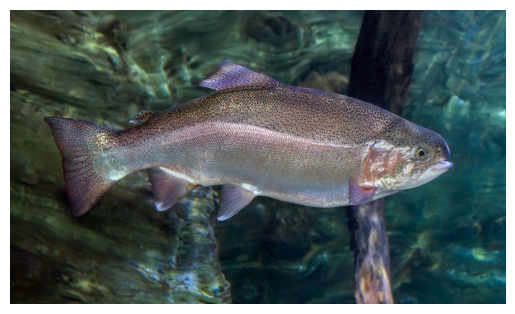


Resultado da Predição para: single_20
Superclasse 20 Esperada: fish
Predição: fish (Confiança: 98.65%)

Resultado da Predição para: single_100
Classe Fina Esperada: trout
Predição: trout (Confiança: 98.92%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: aquatic_life
Superclasse 10: aquatic_life (Confiança: 99.98%)
Classe Fina Esperada: trout
Classe Fina: trout (Confiança: 79.07%)

Teste com imagens novas


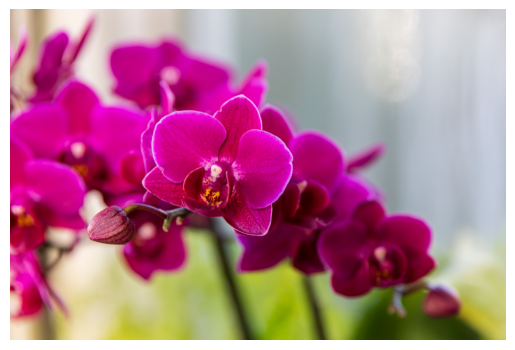


Resultado da Predição para: single_20
Superclasse 20 Esperada: flowers
Predição: flowers (Confiança: 97.55%)

Resultado da Predição para: single_100
Classe Fina Esperada: orchids
Predição: orchid (Confiança: 51.90%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: trees_and_flowers
Superclasse 10: trees_and_flowers (Confiança: 90.19%)
Classe Fina Esperada: orchids
Classe Fina: orchid (Confiança: 85.42%)

Teste com imagens novas


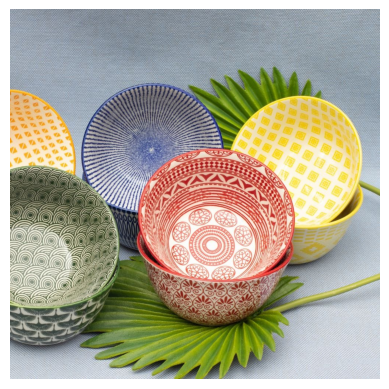


Resultado da Predição para: single_20
Superclasse 20 Esperada: food_containers
Predição: food_containers (Confiança: 99.79%)

Resultado da Predição para: single_100
Classe Fina Esperada: bowls
Predição: bowl (Confiança: 43.73%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: food_containers_and_fruit_and_vegetables
Superclasse 10: food_containers_and_fruit_and_vegetables (Confiança: 99.97%)
Classe Fina Esperada: bowls
Classe Fina: bowl (Confiança: 92.84%)

Teste com imagens novas


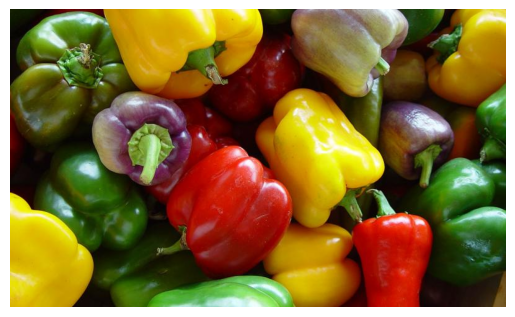


Resultado da Predição para: single_20
Superclasse 20 Esperada: fruit_and_vegetables
Predição: fruit_and_vegetables (Confiança: 95.64%)

Resultado da Predição para: single_100
Classe Fina Esperada: sweet_peppers
Predição: sweet_pepper (Confiança: 48.56%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: food_containers_and_fruit_and_vegetables
Superclasse 10: food_containers_and_fruit_and_vegetables (Confiança: 99.41%)
Classe Fina Esperada: sweet_peppers
Classe Fina: sweet_pepper (Confiança: 81.12%)

Teste com imagens novas


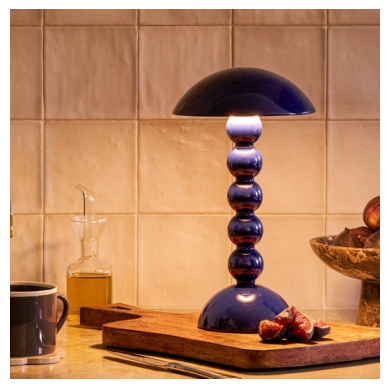


Resultado da Predição para: single_20
Superclasse 20 Esperada: household_electrical_devices
Predição: food_containers (Confiança: 66.12%)

Resultado da Predição para: single_100
Classe Fina Esperada: lamp
Predição: lamp (Confiança: 53.55%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: household_and_furniture
Superclasse 10: household_and_furniture (Confiança: 97.64%)
Classe Fina Esperada: lamp
Classe Fina: lamp (Confiança: 96.54%)

Teste com imagens novas


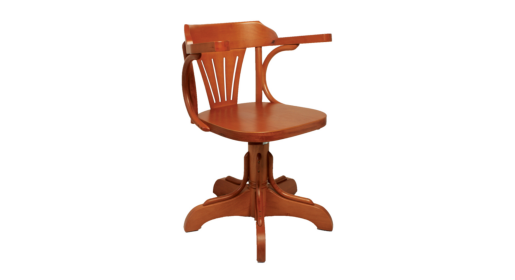


Resultado da Predição para: single_20
Superclasse 20 Esperada: household_furniture
Predição: household_furniture (Confiança: 54.02%)

Resultado da Predição para: single_100
Classe Fina Esperada: chair
Predição: table (Confiança: 55.44%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: household_and_furniture
Superclasse 10: trees_and_flowers (Confiança: 48.90%)
Classe Fina Esperada: chair
Classe Fina: lamp (Confiança: 27.32%)

Teste com imagens novas


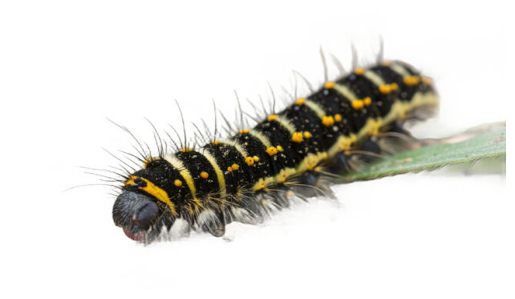


Resultado da Predição para: single_20
Superclasse 20 Esperada: insects
Predição: insects (Confiança: 100.00%)

Resultado da Predição para: single_100
Classe Fina Esperada: caterpillar
Predição: caterpillar (Confiança: 54.45%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: insects_and_non_insect_invertebrates_and_reptiles
Superclasse 10: insects_and_non_insect_invertebrates_and_reptiles (Confiança: 99.96%)
Classe Fina Esperada: caterpillar
Classe Fina: caterpillar (Confiança: 99.53%)

Teste com imagens novas


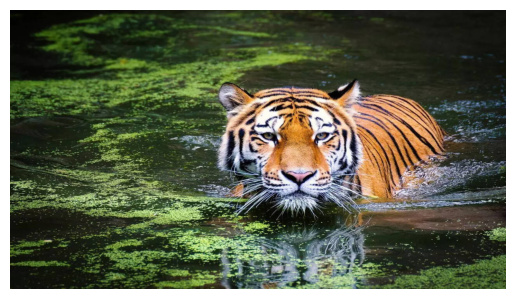


Resultado da Predição para: single_20
Superclasse 20 Esperada: large_carnivores
Predição: large_carnivores (Confiança: 34.93%)

Resultado da Predição para: single_100
Classe Fina Esperada: tiger
Predição: tiger (Confiança: 23.78%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: large_carnivores_and_large_omnivores_and_herbivores
Superclasse 10: insects_and_non_insect_invertebrates_and_reptiles (Confiança: 39.99%)
Classe Fina Esperada: tiger
Classe Fina: aquarium_fish (Confiança: 72.32%)

Teste com imagens novas


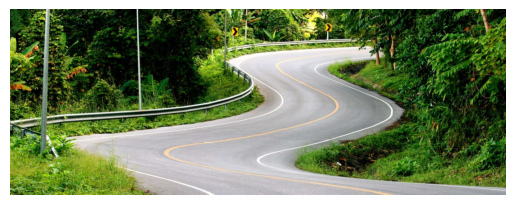


Resultado da Predição para: single_20
Superclasse 20 Esperada: large_man-made_outdoor_things
Predição: large_man-made_outdoor_things (Confiança: 49.04%)

Resultado da Predição para: single_100
Classe Fina Esperada: road
Predição: caterpillar (Confiança: 44.09%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: man_made_outdoor_things_outdoor_scenes
Superclasse 10: insects_and_non_insect_invertebrates_and_reptiles (Confiança: 59.21%)
Classe Fina Esperada: road
Classe Fina: caterpillar (Confiança: 34.11%)

Teste com imagens novas


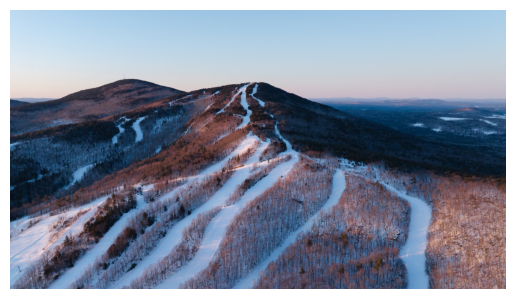


Resultado da Predição para: single_20
Superclasse 20 Esperada: large_natural_outdoor_scenes
Predição: large_man-made_outdoor_things (Confiança: 63.97%)

Resultado da Predição para: single_100
Classe Fina Esperada: mountain
Predição: skyscraper (Confiança: 78.34%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: man_made_outdoor_things_outdoor_scenes
Superclasse 10: man_made_outdoor_things_outdoor_scenes (Confiança: 99.96%)
Classe Fina Esperada: mountain
Classe Fina: mountain (Confiança: 91.51%)

Teste com imagens novas


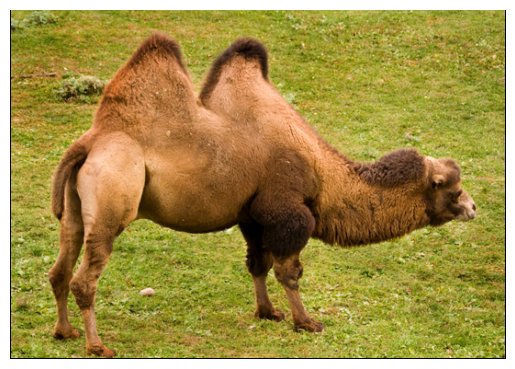


Resultado da Predição para: single_20
Superclasse 20 Esperada: large_omnivores_and_herbivores
Predição: reptiles (Confiança: 77.41%)

Resultado da Predição para: single_100
Classe Fina Esperada: camel
Predição: camel (Confiança: 99.65%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: large_carnivores_and_large_omnivores_and_herbivores
Superclasse 10: large_carnivores_and_large_omnivores_and_herbivores (Confiança: 95.81%)
Classe Fina Esperada: camel
Classe Fina: camel (Confiança: 99.24%)

Teste com imagens novas


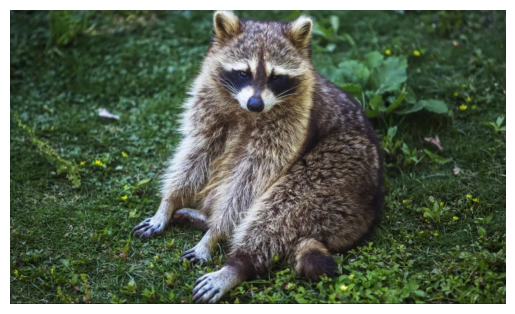


Resultado da Predição para: single_20
Superclasse 20 Esperada: medium_mammals
Predição: medium_mammals (Confiança: 96.52%)

Resultado da Predição para: single_100
Classe Fina Esperada: raccoon
Predição: raccoon (Confiança: 99.59%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: small_mammals_and_medium_mammals
Superclasse 10: small_mammals_and_medium_mammals (Confiança: 98.95%)
Classe Fina Esperada: raccoon
Classe Fina: possum (Confiança: 42.72%)

Teste com imagens novas


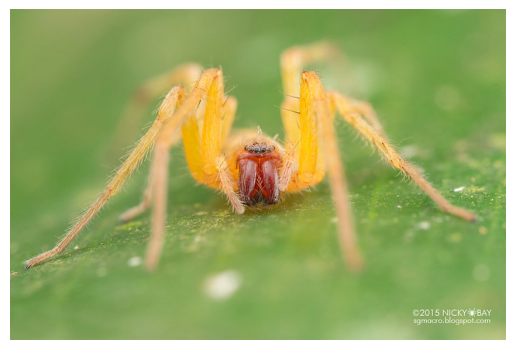


Resultado da Predição para: single_20
Superclasse 20 Esperada: non-insect_invertebrates
Predição: non-insect_invertebrates (Confiança: 68.56%)

Resultado da Predição para: single_100
Classe Fina Esperada: spider
Predição: tulip (Confiança: 54.56%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: insects_and_non_insect_invertebrates_and_reptiles
Superclasse 10: insects_and_non_insect_invertebrates_and_reptiles (Confiança: 97.26%)
Classe Fina Esperada: spider
Classe Fina: spider (Confiança: 91.45%)

Teste com imagens novas


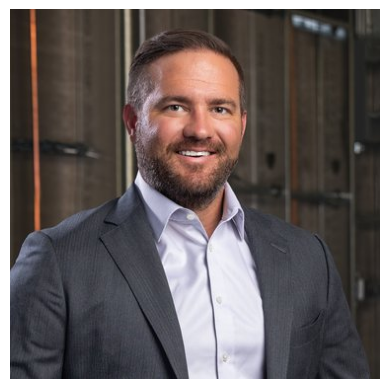


Resultado da Predição para: single_20
Superclasse 20 Esperada: people
Predição: people (Confiança: 100.00%)

Resultado da Predição para: single_100
Classe Fina Esperada: man
Predição: man (Confiança: 98.23%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: people
Superclasse 10: people (Confiança: 99.97%)
Classe Fina Esperada: man
Classe Fina: man (Confiança: 94.71%)

Teste com imagens novas


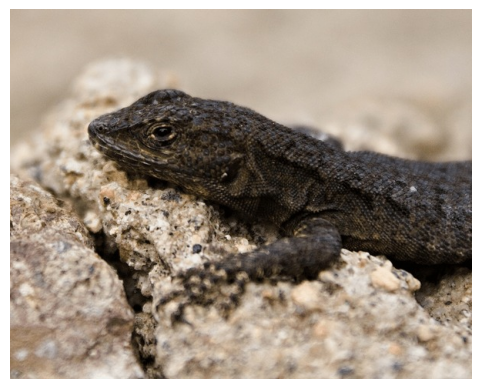


Resultado da Predição para: single_20
Superclasse 20 Esperada: reptiles
Predição: insects (Confiança: 56.71%)

Resultado da Predição para: single_100
Classe Fina Esperada: lizard
Predição: caterpillar (Confiança: 42.57%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: insects_and_non_insect_invertebrates_and_reptiles
Superclasse 10: insects_and_non_insect_invertebrates_and_reptiles (Confiança: 99.55%)
Classe Fina Esperada: lizard
Classe Fina: lizard (Confiança: 99.27%)

Teste com imagens novas


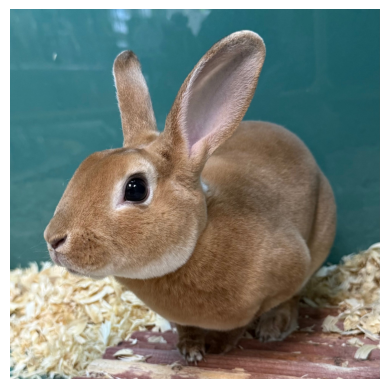


Resultado da Predição para: single_20
Superclasse 20 Esperada: small_mammals
Predição: small_mammals (Confiança: 94.53%)

Resultado da Predição para: single_100
Classe Fina Esperada: rabbit
Predição: rabbit (Confiança: 99.77%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: small_mammals_and_medium_mammals
Superclasse 10: small_mammals_and_medium_mammals (Confiança: 100.00%)
Classe Fina Esperada: rabbit
Classe Fina: rabbit (Confiança: 99.89%)

Teste com imagens novas


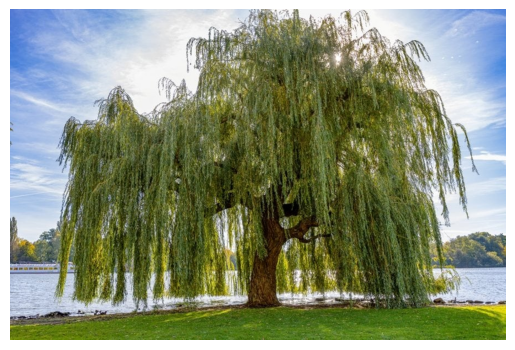


Resultado da Predição para: single_20
Superclasse 20 Esperada: trees
Predição: trees (Confiança: 99.57%)

Resultado da Predição para: single_100
Classe Fina Esperada: willow
Predição: willow_tree (Confiança: 75.21%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: trees_and_flowers
Superclasse 10: trees_and_flowers (Confiança: 98.83%)
Classe Fina Esperada: willow
Classe Fina: willow_tree (Confiança: 45.56%)

Teste com imagens novas


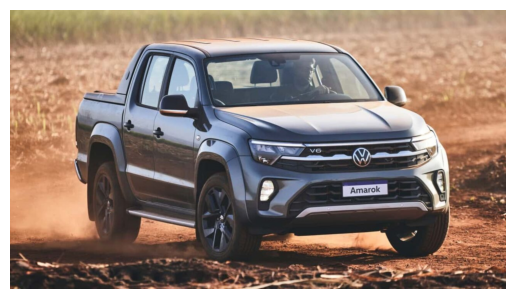


Resultado da Predição para: single_20
Superclasse 20 Esperada: vehicles_1
Predição: household_electrical_devices (Confiança: 54.54%)

Resultado da Predição para: single_100
Classe Fina Esperada: pickup_truck
Predição: train (Confiança: 29.75%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: vehicles
Superclasse 10: small_mammals_and_medium_mammals (Confiança: 53.98%)
Classe Fina Esperada: pickup_truck
Classe Fina: skunk (Confiança: 25.11%)

Teste com imagens novas


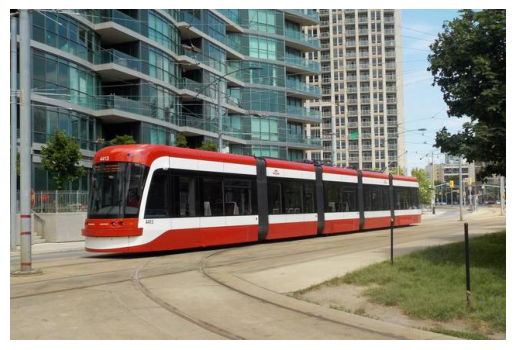


Resultado da Predição para: single_20
Superclasse 20 Esperada: vehicles_2
Predição: vehicles_2 (Confiança: 86.23%)

Resultado da Predição para: single_100
Classe Fina Esperada: streetcar
Predição: streetcar (Confiança: 85.62%)

Resultado da Predição para: multi_10_100
Superclasse 10 Esperada: vehicles
Superclasse 10: vehicles (Confiança: 98.29%)
Classe Fina Esperada: streetcar
Classe Fina: streetcar (Confiança: 65.70%)


In [ ]:
for image_info in new_images_to_predict:
    predict_new_images(image_info['image_url'], image_info['superclasse_20_esperada'], image_info['superclasse_10_esperada'], image_info['classe_fina_esperada'])